In [1]:
import pandas as pd
import os
import sys

# --- Cargar los datasets ---
braaksc = pd.read_csv("../data/genes-braaksc.csv")
ceradsc = pd.read_csv("../data/genes-ceradsc.csv")
cogdx = pd.read_csv("../data/genes-cogdx.csv")

# =========================================================
# SETUP PARA GUARDAR PRINTS (SOLO ESTE BLOQUE)
# =========================================================
os.makedirs("initial_contingency", exist_ok=True)
output_path = "initial_contingency/initial_contingency.txt"

class Tee:
    def __init__(self, *files):
        self.files = files
    def write(self, obj):
        for f in self.files:
            f.write(obj)
    def flush(self):
        for f in self.files:
            f.flush()

original_stdout = sys.stdout
f = open(output_path, "w", encoding="utf-8")
sys.stdout = Tee(sys.stdout, f)

# =========================================================
#  ÍNDICE / LEYENDA DE CLASES
# =========================================================
print("\n================= ÍNDICE DE CLASES =================")

print("\nBraaksc (Estadio de Braak)")
print("0   → Sin patología")
print("1-2 → Afectación inicial (región entorrinal)")
print("3-4 → Etapa intermedia (sistema límbico)")
print("5-6 → Etapa avanzada (neocórtex)")

print("\nCERAD")
print("1 → Alzheimer definitivo (alta densidad de placas)")
print("2 → Alzheimer probable")
print("3 → Alzheimer posible")
print("4 → Sin Alzheimer")

print("\nCogdx")
print("1 → NCI (sin deterioro cognitivo)")
print("2 → MCI (leve sin otras causas)")
print("3 → MCI+ (leve con otras causas)")
print("4 → AD (Alzheimer puro)")
print("5 → AD+ (Alzheimer con comorbilidades)")

# =========================================================
# FUNCIÓN DE CORRESPONDENCIA
# =========================================================
def map_categories(df1, col1, df2, col2, name1, name2):
    print(f"\n--- {name1} → {name2} ---")
    
    classes1 = sorted(df1[col1].dropna().unique())
    classes2 = sorted(df2[col2].dropna().unique())
    
    for c1 in classes1:
        mask1 = (df1[col1] == c1)
        total = mask1.sum()
        
        print(f"\nClase {c1} en {name1}: {total} muestras")
        
        for c2 in classes2:
            count = (mask1 & (df2[col2] == c2)).sum()
            perc = (count / total * 100) if total > 0 else 0
            
            print(f"  → {name2} clase {c2}: {count} ({perc:.2f}%)")

# =========================================================
# Print
# =========================================================
print("\n================= CORRESPODENCIA =================")

map_categories(braaksc, 'braaksc', ceradsc, 'ceradsc', 'Braaksc', 'CERAD')
map_categories(braaksc, 'braaksc', cogdx, 'cogdx', 'Braaksc', 'Cogdx')
map_categories(ceradsc, 'ceradsc', cogdx, 'cogdx', 'CERAD', 'Cogdx')

# =========================================================
# RESTAURAR STDOUT (IMPORTANTE)
# =========================================================
sys.stdout = original_stdout
f.close()


================= ÍNDICE DE CLASES =================

Braaksc (Estadio de Braak)
0   → Sin patología
1-2 → Afectación inicial (región entorrinal)
3-4 → Etapa intermedia (sistema límbico)
5-6 → Etapa avanzada (neocórtex)

CERAD
1 → Alzheimer definitivo (alta densidad de placas)
2 → Alzheimer probable
3 → Alzheimer posible
4 → Sin Alzheimer

Cogdx
1 → NCI (sin deterioro cognitivo)
2 → MCI (leve sin otras causas)
3 → MCI+ (leve con otras causas)
4 → AD (Alzheimer puro)
5 → AD+ (Alzheimer con comorbilidades)

================= CORRESPODENCIA =================

--- Braaksc → CERAD ---

Clase 0 en Braaksc: 6 muestras
  → CERAD clase 1: 0 (0.00%)
  → CERAD clase 2: 0 (0.00%)
  → CERAD clase 3: 0 (0.00%)
  → CERAD clase 4: 6 (100.00%)

Clase 1 en Braaksc: 33 muestras
  → CERAD clase 1: 0 (0.00%)
  → CERAD clase 2: 0 (0.00%)
  → CERAD clase 3: 7 (21.21%)
  → CERAD clase 4: 26 (78.79%)

Clase 2 en Braaksc: 30 muestras
  → CERAD clase 1: 0 (0.00%)
  → CERAD clase 2: 0 (0.00%)
  → CERAD clase 3: 


================= GENERANDO VISUALIZACIONES =================


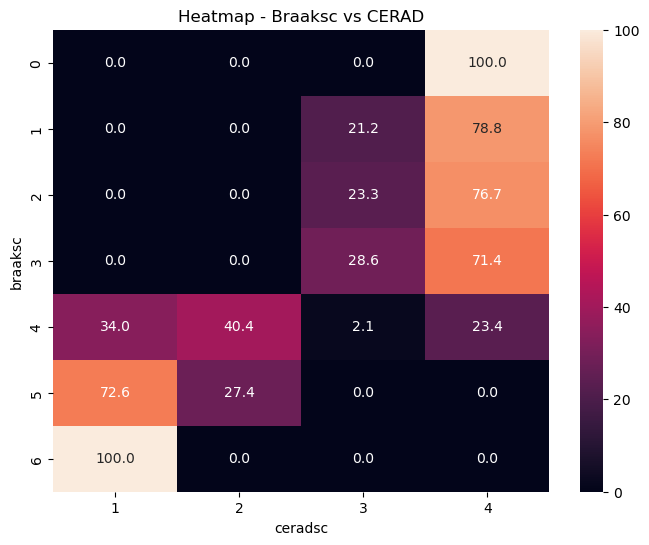

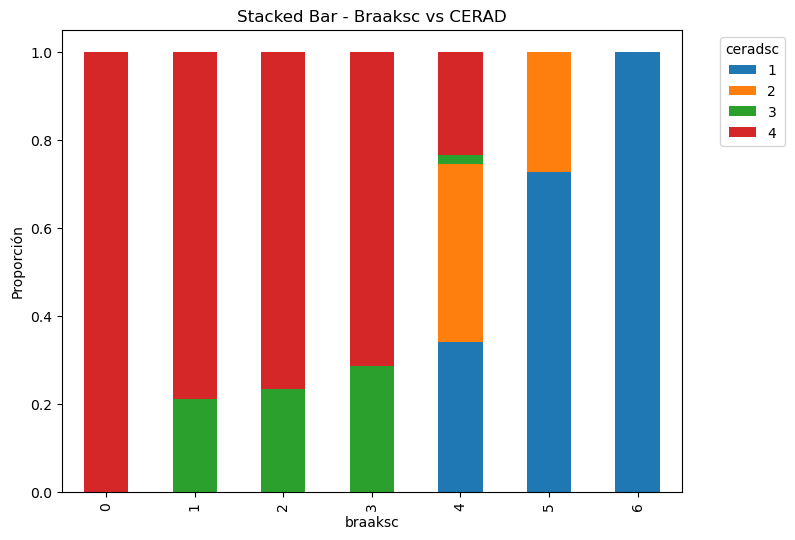

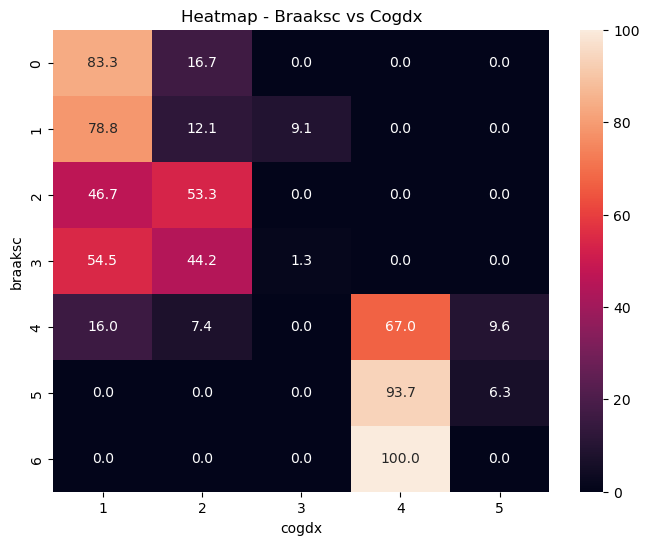

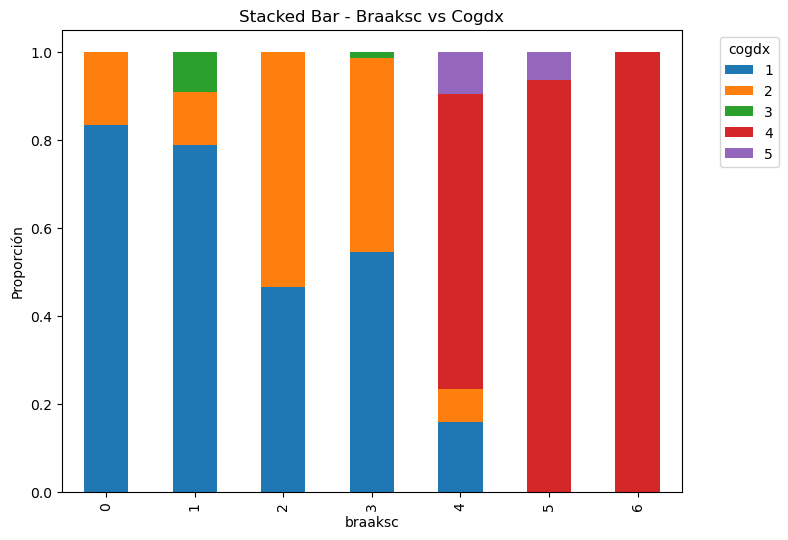

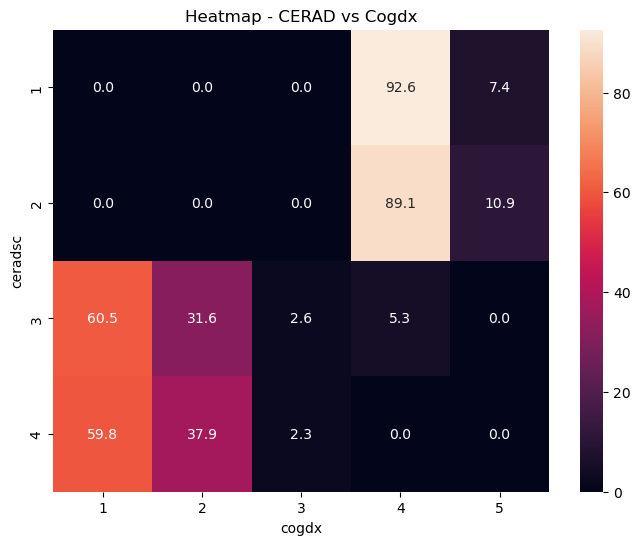

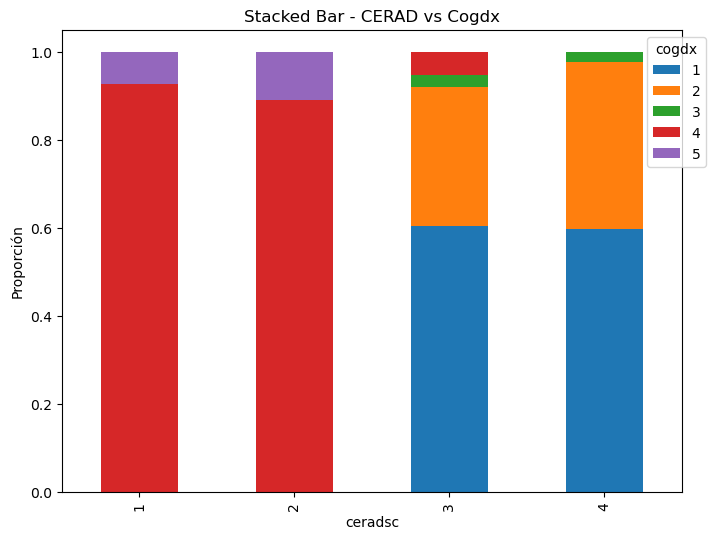


Guardando archivo consolidado en: initial_contingency\plots_initial_contingency.pdf
Proceso finalizado.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import os
from matplotlib.backends.backend_pdf import PdfPages

# --- Configuración de rutas ---
base_dir = "initial_contingency"
plots_dir = os.path.join(base_dir, "plots")
pdf_path = os.path.join(base_dir, "plots_initial_contingency.pdf")

# Crear carpetas si no existen
os.makedirs(plots_dir, exist_ok=True)

# --- Cargar datos ---
braaksc = pd.read_csv("../data/genes-braaksc.csv")
ceradsc = pd.read_csv("../data/genes-ceradsc.csv")
cogdx = pd.read_csv("../data/genes-cogdx.csv")

# Lista para almacenar las figuras de Matplotlib y guardarlas en el PDF al final
pdf_figures = []

# =========================================================
# FUNCIONES DE VISUALIZACIÓN
# =========================================================

def plot_heatmap(df1, col1, df2, col2, title):
    table = pd.crosstab(df1[col1], df2[col2], normalize='index') * 100
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(table, annot=True, fmt=".1f", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col2)
    ax.set_ylabel(col1)
    
    # Guardar individual
    filename = title.replace(" ", "_").lower() + ".png"
    fig.savefig(os.path.join(plots_dir, filename), bbox_inches='tight')
    pdf_figures.append(fig)
    plt.show()

def plot_stacked_bar(df1, col1, df2, col2, title):
    table = pd.crosstab(df1[col1], df2[col2], normalize='index')
    
    fig, ax = plt.subplots(figsize=(8, 6))
    table.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col1)
    ax.set_ylabel("Proporción")
    ax.legend(title=col2, bbox_to_anchor=(1.05, 1))
    
    # Guardar individual
    filename = title.replace(" ", "_").lower() + ".png"
    fig.savefig(os.path.join(plots_dir, filename), bbox_inches='tight')
    pdf_figures.append(fig)
    plt.show()

def plot_sankey(df1, col1, df2, col2, title):
    table = pd.crosstab(df1[col1], df2[col2])

    labels = list(table.index.astype(str)) + list(table.columns.astype(str))
    source, target, value = [], [], []

    for i, src in enumerate(table.index):
        for j, tgt in enumerate(table.columns):
            v = table.loc[src, tgt]
            if v > 0:
                source.append(i)
                target.append(len(table.index) + j)
                value.append(v)

    fig = go.Figure(data=[go.Sankey(
        node=dict(label=labels),
        link=dict(source=source, target=target, value=value)
    )])

    fig.update_layout(title_text=title)
    
    # Guardar individual (Requiere: pip install kaleido)
    filename = title.replace(" ", "_").lower() + ".png"
    try:
        fig.write_image(os.path.join(plots_dir, filename))
    except Exception as e:
        print(f"Nota: No se pudo guardar la imagen del Sankey. Asegúrate de tener 'kaleido' instalado. Error: {e}")
    
    fig.show()

# =========================================================
# LISTA DE CRUCES
# =========================================================

cruces = [
    (braaksc, 'braaksc', ceradsc, 'ceradsc', 'Braaksc vs CERAD'),
    (braaksc, 'braaksc', cogdx, 'cogdx', 'Braaksc vs Cogdx'),
    (ceradsc, 'ceradsc', cogdx, 'cogdx', 'CERAD vs Cogdx'),
]

# =========================================================
# EJECUCIÓN
# =========================================================

print("\n================= GENERANDO VISUALIZACIONES =================")

for df1, col1, df2, col2, title in cruces:
    plot_heatmap(df1, col1, df2, col2, f"Heatmap - {title}")
    plot_stacked_bar(df1, col1, df2, col2, f"Stacked Bar - {title}")
    plot_sankey(df1, col1, df2, col2, f"Sankey - {title}")

# =========================================================
# GUARDAR PDF CONSOLIDADO
# =========================================================
print(f"\nGuardando archivo consolidado en: {pdf_path}")
with PdfPages(pdf_path) as pdf:
    for fig in pdf_figures:
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig) # Liberar memoria

print("Proceso finalizado.")

In [3]:
pip install -U plotly

Note: you may need to restart the kernel to use updated packages.
